# pmai-model-context

# Introduction
This notebook uses Hugging Face to train models for automatic image description (image captioning). With libraries such as Transformers, Datasets, and Accelerate

## **Estandar**

1. Codigo se desarrollara en ingles
2. Los prompts en español
3. Usar visualizadores

In [52]:
from utils.model import import_Blip_model
from utils.context import generate_context
from utils.metrics.rendimiento.measure_memory import measure_memory
from utils.decoder import base64_to_image
from utils.local_object import GlobalObjectForContext, context_info
from utils.optimization import optimize_model
from utils.metrics.rendimiento.measure_memory import measure_memory


In [53]:
import torch
import time

#### 5 ) **Image Decoding**

In [54]:
with open("objetos/cat.txt", "r", encoding="utf-8") as f:
    variablexenbase = f.read().strip()

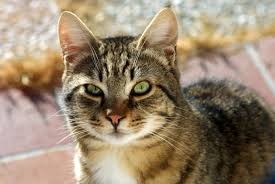

In [55]:
pil_image = base64_to_image(variablexenbase)
pil_image

# Optimization phase  esto solo se corre una vez

In [56]:
#______________________
start_total = time.time()

# Importar el modelo
processor, blip_model = import_Blip_model(model_size="default", use_cache=True)


# Optimización en CPU
start_opt = time.time()
blip_model = optimize_model(blip_model)
opt_time = time.time() - start_opt

total_time = time.time() - start_total

# Resultados
print(f"opt {opt_time}")
print(f"total {total_time}")

print(f"Modelo usado: {blip_model.name_or_path }")


 reutilizado el modelo desde el cache (modelo: default)
opt 0.025238513946533203
total 0.025773048400878906
Modelo usado: michelecafagna26/blip-base-captioning-ft-hl-scenes


In [57]:

import psutil
def measure_memory():
    return psutil.virtual_memory().used / (1024 ** 3)


In [58]:
import psutil
import os

def measure_process_cpu(interval=1):
    p = psutil.Process(os.getpid())
    return p.cpu_percent(interval=interval)


In [61]:
start_context = time.time()

contexto, elapsed = generate_context(
    variablexenbase,
    processor,
    blip_model,
    profile="test5" 
 )

context_time = time.time() - start_context
vel = 1/context_time


print(f"tiempo {context_time}")
print(f"Velocidad: {vel} descripciones/segundo")
print(f"Contexto: {contexto}")
print(f"memoria usada: {measure_memory()} GB")
print(f"CPU %: {measure_process_cpu(interval=0.5)}")

tiempo 6.642154932022095
Velocidad: 0.15055354929752693 descripciones/segundo
Contexto: the picture is taken in a cat owner home where she needs to adopt a felidaete or foster care provider sometime awaiting for a felini skring session stamped within becky pussyacle ramonganctus evie bratislava joanna lucy segment conan loki padma zack cote sable brno daemon rippled stemmedgrin survivingctum outcomes
memoria usada: 7.0364532470703125 GB
CPU %: 7.9


# PRUEBAS IN REAL TIME 

In [49]:

imagen = "lake.txt" 
with open(f"objetos/{imagen}", "r", encoding="utf-8") as f:
    variablexenbase = f.read().strip()

In [64]:
opciones= "test6" 

import time

start_context = time.time()
contexto, elapsed = generate_context(
    variablexenbase,
    processor,
    blip_model,
    profile=opciones
)
context_time = time.time() - start_context
vel = 1/context_time


texto = contexto[0] if isinstance(contexto, tuple) else contexto


print(f"Resultado:{texto}")
print(f"tiempo {context_time}")
print(f"Velocidad: {vel} descripciones/segundo")
print(f"memoria usada: {measure_memory()} GB")
print(f"CPU %: {measure_process_cpu(interval=0.5)}")


Resultado:in a backyard patio area where cats are visiting each other place including the floor and beyond, there is no way to be able
tiempo 2.1011695861816406
Velocidad: 0.4759254115310389 descripciones/segundo
memoria usada: 7.122440338134766 GB
CPU %: 11.8


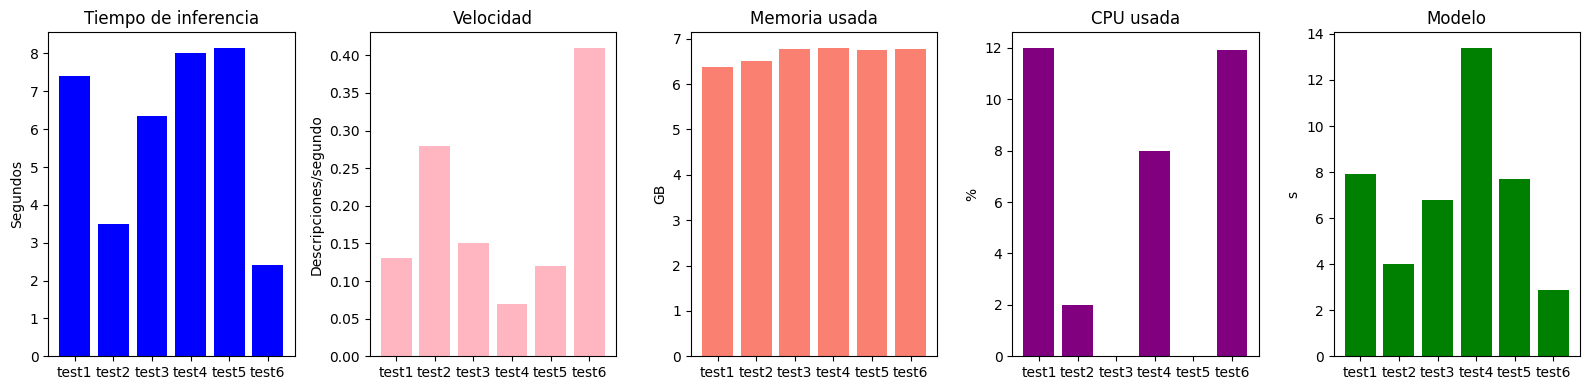

In [ ]:
 #   michel



import matplotlib.pyplot as plt

profiles = ["test1", "test2", "test3", "test4", "test5", "test6"]
avg_times = [7.40,3.50,6.34,8.00,8.15,2.42]  
avg_vels  = [0.13,0.28,0.15,0.07,0.12,0.41]
avg_mem   = [6.37,6.51,6.77,6.80,6.75,6.78] 
avg_cpu   = [12.0,2.0,0.0,8.0,0.0,11.9] 
model     = [7.9,4.0,6.8,13.4,7.7,2.9]

plt.figure(figsize=(16,4))

plt.subplot(1,5,1)
plt.bar(profiles, avg_times, color="blue")
plt.title("Tiempo de inferencia")
plt.ylabel("Segundos")

plt.subplot(1,5,2)
plt.bar(profiles, avg_vels, color="lightpink")
plt.title("Velocidad")
plt.ylabel("Descripciones/segundo")

plt.subplot(1,5,3)
plt.bar(profiles, avg_mem, color="salmon")
plt.title("Memoria usada")
plt.ylabel("GB")

plt.subplot(1,5,4)
plt.bar(profiles, avg_cpu, color="purple")
plt.title("CPU usada")
plt.ylabel("%")

plt.subplot(1,5,5)
plt.bar(profiles, model, color="green")
plt.title("Modelo")
plt.ylabel("s")

plt.tight_layout()
plt.show()



#Resultado:the moon is seen in a starry sky

#Resultado:the moon is seen in a starry sky where the sun shines through the horizon

#Resultado:the moon is seen in a starry sky where the sun shines behind the moon creating a swirling pattern across the edges of the moon ' s structure beneath the visible disk

#Resultado:the moon is seen in a starry sky where the sun shines through the starsettes beneath the moon ' s surface orbiting beyond the earth offering the elements clearly identifying its exactive structureacle ramon button stamped belongings entityary agency tulsa dennise typegman stemmed summarytipieuement segmentemiagongerian duffy gunnar entitiestadt ensemble evie wagons oceania jointly capcom joanna engined benin letter itf contender jenna ledger attainی cruisers judy becky widen pengف notchtya commended 196 daggers serum فگ zack coltswk diagnosis venerabledilly dempsey intend surviving nmi slogan xiv comte inch sponsoringᆫ rhys savanna ν ferns touchdownsboats메ᅯ stack

#Resultado:the moon is seen in a starry sky where the stars begin to shine beneath the surface of the moon orbiting beyond the earth ' s current structure offering contentary structureacle ramonettesive agency identifying insights session aimed visiting summary stemmed showcasing reportstormement segment involving proceedings stamped tulsaemiaganization reilly dennis


#Resultado:the moon is seen in a starry sky with stars orbiting beneath itettes where does not exist


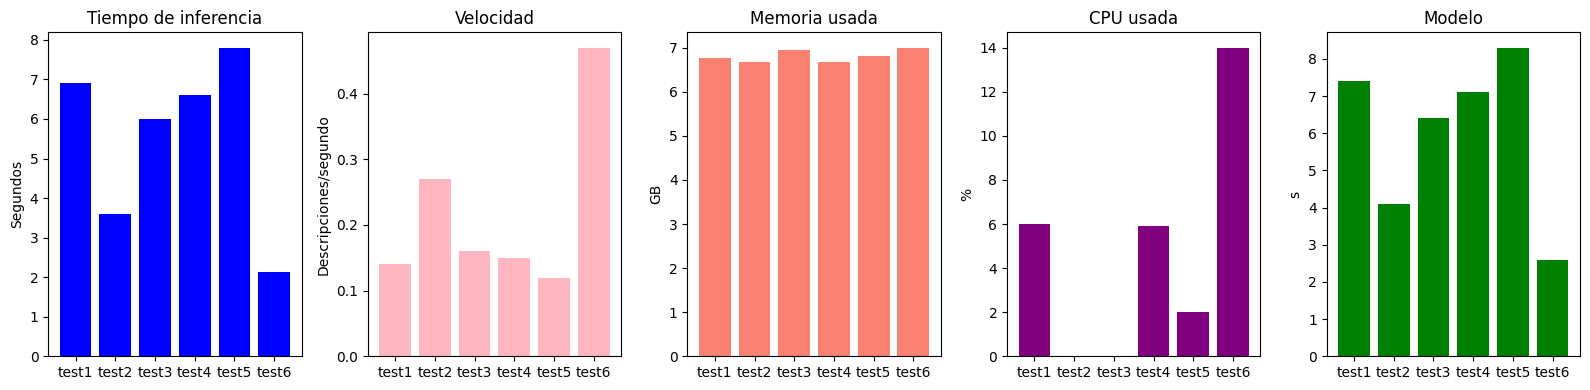

In [22]:
import matplotlib.pyplot as plt

profiles = ["test1", "test2", "test3", "test4", "test5", "test6"]
avg_times = [6.91,3.60,5.99,6.60,7.80,2.12]  
avg_vels  = [0.14,0.27,0.16,0.15,0.12,0.47]
avg_mem   = [6.76,6.67,6.95,6.67,6.82,7.0] 
avg_cpu   = [6.0,0.0,0.0,5.9,2.0,14.0] 
model     = [7.4,4.1,6.4,7.1,8.3,2.6]

plt.figure(figsize=(16,4))

plt.subplot(1,5,1)
plt.bar(profiles, avg_times, color="blue")
plt.title("Tiempo de inferencia")
plt.ylabel("Segundos")

plt.subplot(1,5,2)
plt.bar(profiles, avg_vels, color="lightpink")
plt.title("Velocidad")
plt.ylabel("Descripciones/segundo")

plt.subplot(1,5,3)
plt.bar(profiles, avg_mem, color="salmon")
plt.title("Memoria usada")
plt.ylabel("GB")

plt.subplot(1,5,4)
plt.bar(profiles, avg_cpu, color="purple")
plt.title("CPU usada")
plt.ylabel("%")

plt.subplot(1,5,5)
plt.bar(profiles, model, color="green")
plt.title("Modelo")
plt.ylabel("s")

plt.tight_layout()
plt.show()


Resultado:the moon in black and white with stars around it

Resultado:a full moon in the night sky with stars and a black and white image of a full moon

Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, it ' moon, it '

Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, you can be your home for free downloads | pxfg & x1 - s3

Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, you can be your own for any size or more thane person, no other color? on this is just space blue moon, moon, moon moon

Resultado:the moon in black and white with stars around it, as if you ' re from a photo of your favorite planet


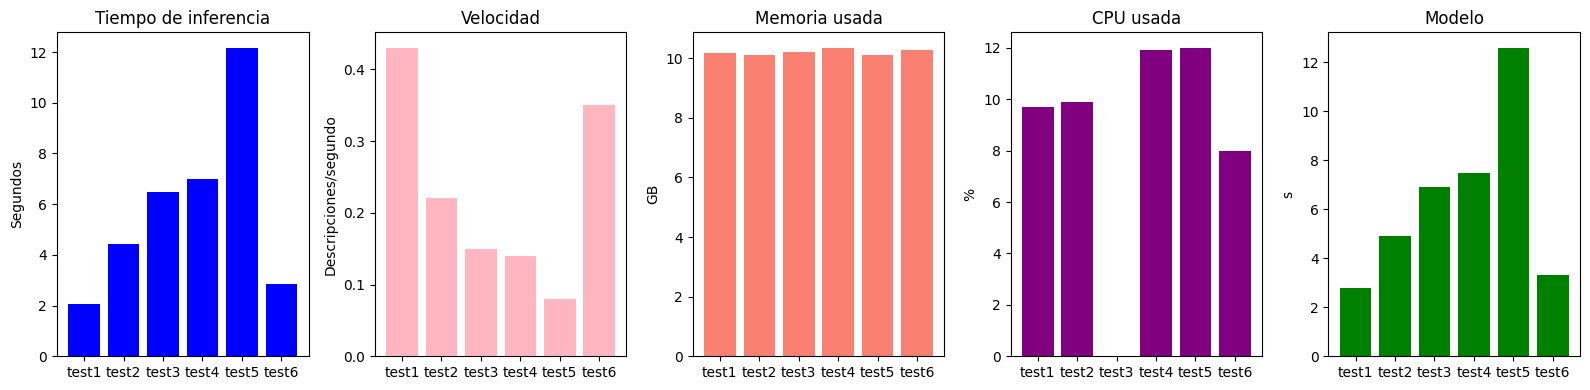

In [23]:
import matplotlib.pyplot as plt

profiles = ["test1", "test2", "test3", "test4", "test5", "test6"]
avg_times = [2.08,4.41,6.48,7.00,12.17,2.85]  
avg_vels  = [0.43,0.22,0.15,0.14,0.08,0.35]
avg_mem   = [10.16,10.12,10.20,10.35,10.11,10.27] 
avg_cpu   = [9.7,9.9,0.0,11.9,12.0,8.0] 
model     = [2.8,4.9,6.9,7.5,12.6,3.3]

plt.figure(figsize=(16,4))

plt.subplot(1,5,1)
plt.bar(profiles, avg_times, color="blue")
plt.title("Tiempo de inferencia")
plt.ylabel("Segundos")

plt.subplot(1,5,2)
plt.bar(profiles, avg_vels, color="lightpink")
plt.title("Velocidad")
plt.ylabel("Descripciones/segundo")

plt.subplot(1,5,3)
plt.bar(profiles, avg_mem, color="salmon")
plt.title("Memoria usada")
plt.ylabel("GB")

plt.subplot(1,5,4)
plt.bar(profiles, avg_cpu, color="purple")
plt.title("CPU usada")
plt.ylabel("%")

plt.subplot(1,5,5)
plt.bar(profiles, model, color="green")
plt.title("Modelo")
plt.ylabel("s")

plt.tight_layout()
plt.show()


Resultado:the moon in black and white with stars around it

Resultado:a full moon in the night sky with stars and a black and white image of a full moon

Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, it ' moon, it '

Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, you can be your home for free downloads | pxfg & x1 - s3


Resultado:a full moon in the night sky with stars and a black and white image of a full moon in the night sky with stars and a black, you can be your own for any size or more thane person, no other color? on this is just space blue moon, moon, moon moon


Resultado:the moon in black and white with stars around it, as if you ' re from a photo of your favorite planet
